# Project Work NLP: Analisi della Distorsione e Omogeneizzazione della Scrittura da parte degli LLM

Questo notebook esplora l'impatto dei Modelli Linguistici di Grandi Dimensioni (LLM) sulla scrittura umana, implementando un'analisi basata su due recenti studi:

1. L'analisi di *"How LLMs Distort Our Written Language"* (2026), che dimostra come l'uso dell'IA come co-pilota di scrittura tenda a cancellare l'identità dell'autore, generando una "voce algoritmica" omogeneizzata.
2. L'indagine di *"Scientific production in the era of large language models"* (Science, 2025), che evidenzia come l'IA alteri la complessità linguistica spingendo verso un linguaggio iper-formale e artificiale.

Al fine di approfondire sperimentalmente i risultati emersi, questo project work è organizzato in tre esperimenti, ognuno dedicato all'analisi di uno specifico effetto degli LLM sulla produzione testuale.

* **Esperimento 1 - Evoluzione Temporale delle Metriche Linguistiche:** analisi di come varia la prevedibilità statistica e la complessità strutturale del testo passando dalla bozza umana iniziale, alla revisione manuale, fino alla revisione artificiale (utilizzando il dataset *ArgRewrite*).
* **Esperimento 2 — Classificazione Stilistica Multiclasse:** studio comparativo volto a identificare le firme stilistiche dell'IA rispetto al processo di scrittura e revisione umana. L'analisi mette a confronto una rappresentazione basata su TF-IDF combinata con regressione logistica e una rappresentazione avanzata ottenuta tramite il fine-tuning del modello Transformer *DistilBERT*.
* **Esperimento 3 - Ridondanza Interna e Omogeneizzazione Lessicale:** analisi ispirata alla metodologia degli studi sull'omogeneizzazione generata dall'IA (es. ICLR 2026) per valutare sia la **ridondanza interna al documento** sia l'**omogeneizzazione stilistica e semantica inter-documento** sul dataset *HC3 Finance*.

---

### Configurazione dell'Ambiente e Importazione delle Librerie
In questa cella viene configurato l'ambiente importando i pacchetti necessari per la manipolazione dei dati (es. `pandas`, `numpy`), la visualizzazione grafica (es. `matplotlib`, `seaborn`), l'estrazione di feature tradizionali e la modellazione classica (es. `scikit-learn`), e il calcolo delle metriche linguistiche avanzate (es. `transformers`, `nltk`, `textstat`, `sentence-transformers`).

In [ ]:
import gc
import os
import re
from datasets import load_dataset
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay,confusion_matrix, classification_report)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import textstat
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (DistilBertForSequenceClassification,DistilBertTokenizer,GPT2LMHeadModel,GPT2Tokenizer)
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Download risorse NLTK
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# Impostazioni grafiche
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

### Caricamento e Strutturazione dei Dati

Prima di estrarre le metriche linguistiche, strutturiamo il dataset in modo da allineare ogni singolo saggio lungo il suo ciclo vitale. 

Attraverso l'integrazione del corpus **ArgRewrite V.2** (per i testi umani) e delle riscritture contenute in `dataframe_essays_llm_model.csv` (per i modelli generativi), costruiamo un unico DataFrame unificato (`df_timeline`).

Nello specifico, il dataset comprende **86 saggi umani unici**, ciascuno affiancato a 30 riscritture IA differenti (derivate da più modelli e prompt). Ciascuna riga del DataFrame allinea il percorso evolutivo su tre stadi:

1. **$t_0$ - Bozza Iniziale**: il testo grezzo scritto dallo studente prima di ricevere feedback (`Draft1`).
2. **$t_1$ - Revisione Umana**: l'evoluzione naturale del saggio rivista dallo studente a seguito dei commenti (`Draft2`).
3. **$t_1^*$ - Riscrittura IA**: la revisione parallela generata da LLM di riferimento a partire dalla bozza $t_0$.

Per evitare distorsioni nelle analisi descrittive dei testi umani (dovute alla ripetizione dei testi $t_0$ e $t_1$ sulle 30 varianti IA), isoliamo un sottoinsieme deduplicato composto dai soli 86 saggi umani unici (`df_umani_unici`). Questo allineamento ci permetterà di confrontare direttamente la traiettoria evolutiva della scrittura umana contro la traiettoria di riscrittura dell'IA.

In [4]:
PATH_ANALYSIS = "./data/argrewrite_analysis"
csv_real_path = os.path.join(PATH_ANALYSIS, "dataframe_essays_llm_model.csv")

if os.path.exists(csv_real_path):
    df_raw = pd.read_csv(csv_real_path)
    
    modelli_disponibili = df_raw["llm_model"].unique()

    df_filtered = df_raw.copy()
    
    # costruzione del DataFrame
    df_timeline = pd.DataFrame({
        "essay_id": df_filtered["essay_id"],
        "t0_bozza": df_filtered["draft1"],
        "t1_umano": df_filtered["draft2"],
        "t1_ia": df_filtered["ai_text"],
        "llm_model": df_filtered["llm_model"]
    }).dropna().reset_index(drop=True)
    
    df_umani_unici = df_timeline.drop_duplicates(subset=["essay_id"]).reset_index(drop=True)
    
    print(f"[DATA] Caricamento completato con successo.")
    print(f"[DATA] Totale righe dataset (varianti IA comprese): {len(df_timeline)}")
    print(f"[DATA] Totale saggi umani unici (essay_id): {df_umani_unici['essay_id'].nunique()}")
else:
    raise FileNotFoundError(f"Impossibile trovare il file: {csv_real_path}")

[DATA] Caricamento completato con successo.
[DATA] Totale righe dataset (varianti IA comprese): 2580
[DATA] Totale saggi umani unici (essay_id): 86


---

## Esperimento 1 - Evoluzione Temporale delle Metriche Linguistiche

### Obiettivo
In questo primo esperimento misuriamo come si trasforma l'impronta stilistica di un testo durante il suo processo di revisione. La letteratura scientifica suggerisce che l'intervento di un LLM tenda ad "appiattire" il testo, rendendolo più prevedibile e strutturalmente monotono, aumentandone però la complessità sintattica e lessicale.

Analizzeremo l'evoluzione delle grandezze testuali confrontando tre fasi temporali distinte:

1. **$t_0$ - Bozza Iniziale:** il saggio originale scritto dallo studente.
2. **$t_1$ - Revisione Manuale:** il saggio corretto dallo studente seguendo il feedback del docente.
3. **$t_1^*$ - Riscrittura IA:** il saggio originale fatto correggere a un modello IA.

### Metriche Calcolate e Parametri di Elaborazione
Per tracciare questa evoluzione estrarremo quattro grandezze fondamentali:

* **Entropia:** misura il grado di incertezza del modello nel prevedere la parola successiva. Nello specifico, è calcolata come cross-entropy loss utilizzando il modello base GPT-2. Testi fortemente standardizzati dall'IA presentano un'entropia minore.
* **Perplessità:** direttamente derivata dall'entropia, indica quanto il testo sia "sorprendente" per un modello linguistico:
  $$Perplexity = \exp(Entropy)$$
* **Burstiness:** valuta la varianza nella lunghezza delle frasi. Gli esseri umani alternano frasi brevi e lunghe (alta burstiness), mentre l'IA tende a produrre strutture di lunghezza uniforme. È calcolata tramite la deviazione standard del numero di parole per frase.
* **Leggibilità Flesch:** un indice per quantificare la facilità di lettura basato su sillabe e lunghezza delle parole. L'obiettivo è verificare se la revisione dell'IA introduca una complessità sintattica artificiale rispetto alla revisione umana.

> **Nota:** L'analisi è limitata ai primi 512 token per saggio (`max_length=512`) per rispettare i vincoli di memoria hardware di elaborazione CPU e garantire un confronto omogeneo tra i testi.

### Estrattore Metriche Linguistiche

L'estrazione viene eseguita in modalità vettorializzata e isolata: per gli stadi $t_0$ e $t_1$ le metriche vengono calcolate esclusivamente sull'insieme unico dei 86 saggi umani per poi essere mappate nel DataFrame generale, mentre per $t_1^*$ vengono elaborate tutte le 2580 riscritture IA.

In [5]:
device = "cpu"

print("=" * 70)
print("ESPERIMENTO 1: CALCOLO DELLE METRICHE LINGUISTICHE")
print("=" * 70)
print(f"Dispositivo in uso: {device.upper()}")

# Inizializzazione GPT-2 per entropia e perplessità
gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt_model.eval()

def calcola_entropia_perplessita(testo):
    if not isinstance(testo, str) or not testo.strip():
        return np.nan, np.nan
    
    inputs = gpt_tokenizer(testo, return_tensors="pt", truncation=True, max_length=512).to(device)
    if inputs.input_ids.shape[1] < 2:
        return np.nan, np.nan
        
    with torch.no_grad():
        outputs = gpt_model(inputs.input_ids, labels=inputs.input_ids)
        loss = outputs.loss.item()
        perplexity = float(np.exp(loss))
        
    return loss, perplexity

stadi = [
    ("t0", "t0_bozza", "$t_0$ Bozza Umana", True),
    ("t1_h", "t1_umano", "$t_1$ Revisione Umana", True),
    ("t1_ai", "t1_ia", "$t_1^*$ Riscrittura IA", False)
]

for prefisso, col_testo, nome_stadio, usa_unici in stadi:
    df_target = df_umani_unici if usa_unici else df_timeline
    totale = len(df_target)
    
    print(f"\n[{nome_stadio}] Processamento su {totale} testi...")
    entropie, perplessita, burstiness, leggibilita = [], [], [], []
    
    for i, row in enumerate(df_target.itertuples(), start=1):
        testo = getattr(row, col_testo)
        e, p = calcola_entropia_perplessita(testo)
        
        # burstiness e leggibilità
        if isinstance(testo, str) and testo.strip():
            frasi = nltk.sent_tokenize(testo)
            b = (float(np.std([len(nltk.word_tokenize(f)) for f in frasi])) if len(frasi) > 1 else 0.0)
            l = textstat.flesch_reading_ease(testo)
        else:
            b, l = 0.0, np.nan
            
        entropie.append(e)
        perplessita.append(p)
        burstiness.append(b)
        leggibilita.append(l)
        
        if i % 10 == 0 or i == totale:
            print(f"  Progressione: {i:>4}/{totale} ({i/totale*100:5.1f}%)", end="\r")
    
    # assegnazione dei risultati
    if usa_unici:
        df_umani_unici[f"{prefisso}_entropy"] = entropie
        df_umani_unici[f"{prefisso}_perplexity"] = perplessita
        df_umani_unici[f"{prefisso}_burstiness"] = burstiness
        df_umani_unici[f"{prefisso}_readability"] = leggibilita
        
        # mappiamo su df_timeline usando l'essay_id come chiave
        for metrica in ["entropy", "perplexity", "burstiness", "readability"]:
            mapping = dict(zip(df_umani_unici["essay_id"], df_umani_unici[f"{prefisso}_{metrica}"]))
            df_timeline[f"{prefisso}_{metrica}"] = df_timeline["essay_id"].map(mapping)
    else:
        # IA assegniamo direttamente a df_timeline
        df_timeline[f"{prefisso}_entropy"] = entropie
        df_timeline[f"{prefisso}_perplexity"] = perplessita
        df_timeline[f"{prefisso}_burstiness"] = burstiness
        df_timeline[f"{prefisso}_readability"] = leggibilita
        
    print(f"\n  Completato per {nome_stadio}")

torch.cuda.empty_cache()

ESPERIMENTO 1: CALCOLO DELLE METRICHE LINGUISTICHE
Dispositivo in uso: CPU


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


[$t_0$ Bozza Umana] Processamento su 86 testi...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Progressione:   86/86 (100.0%)
  Completato per $t_0$ Bozza Umana

[$t_1$ Revisione Umana] Processamento su 86 testi...
  Progressione:   86/86 (100.0%)
  Completato per $t_1$ Revisione Umana

[$t_1^*$ Riscrittura IA] Processamento su 2580 testi...
  Progressione: 2580/2580 (100.0%)
  Completato per $t_1^*$ Riscrittura IA


### Visualizzazione Grafica comparativa

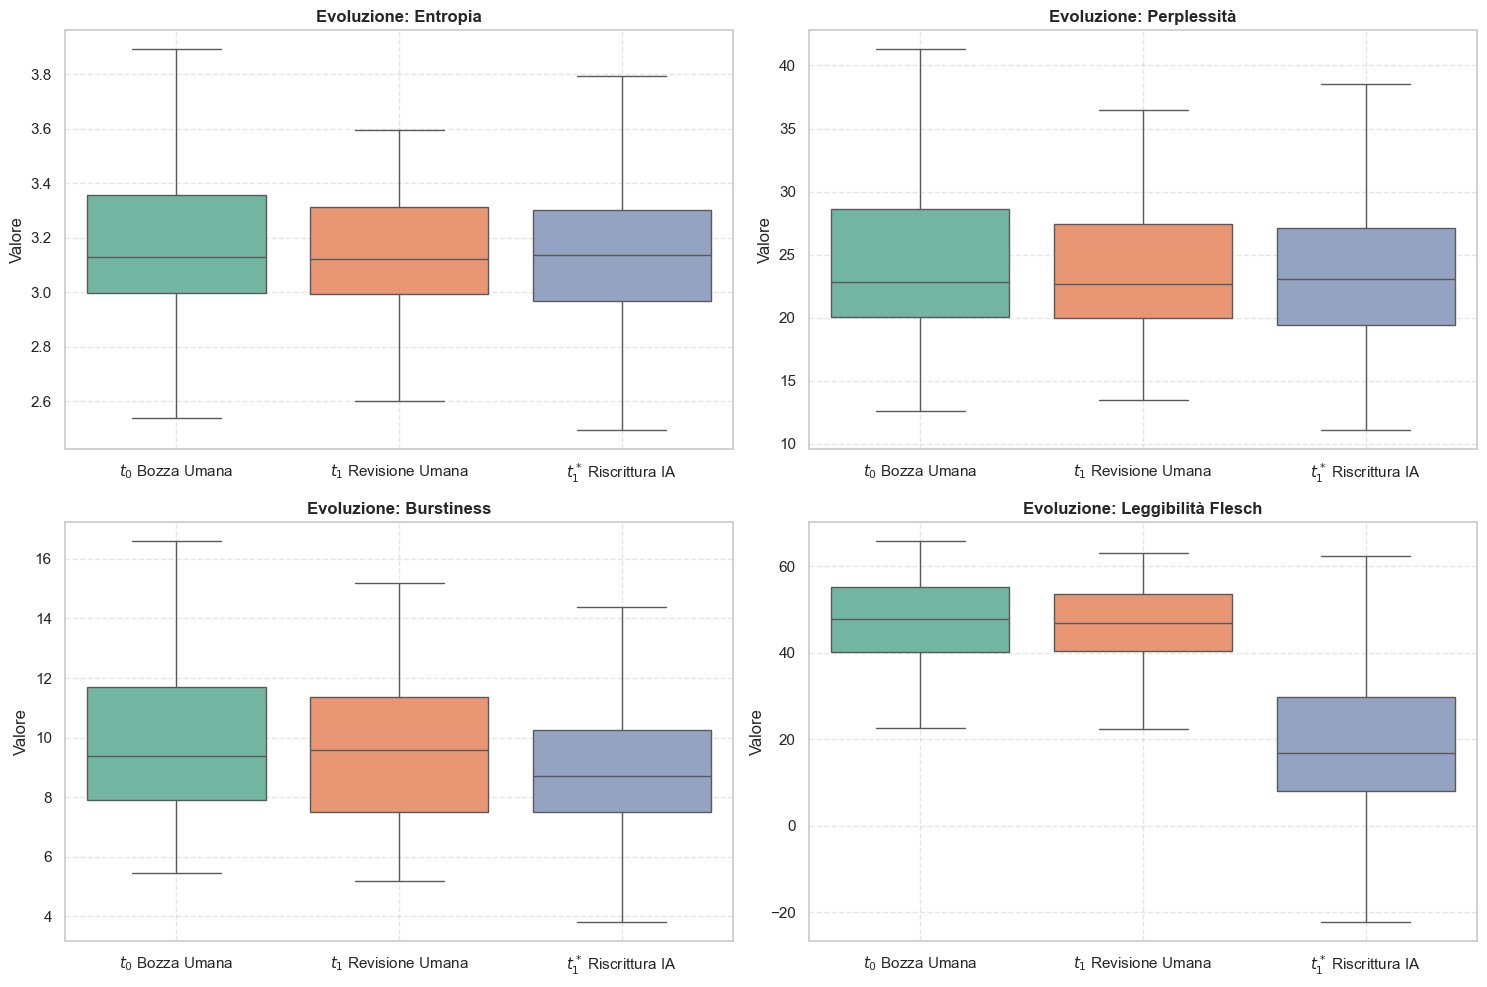

In [6]:
metrics_to_plot = [
    ("entropy", "Entropia"),
    ("perplexity", "Perplessità"),
    ("burstiness", "Burstiness"),
    ("readability", "Leggibilità Flesch")
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (metric_code, metric_name) in enumerate(metrics_to_plot):
    df_t0 = pd.DataFrame({"Stadio": "$t_0$ Bozza Umana", "Valore": df_umani_unici[f"t0_{metric_code}"]})
    df_t1_h = pd.DataFrame({"Stadio": "$t_1$ Revisione Umana", "Valore": df_umani_unici[f"t1_h_{metric_code}"]})
    df_t1_ai = pd.DataFrame({"Stadio": "$t_1^*$ Riscrittura IA", "Valore": df_timeline[f"t1_ai_{metric_code}"]})
    
    df_plot = pd.concat([df_t0, df_t1_h, df_t1_ai], ignore_index=True)
    
    sns.boxplot(
        data=df_plot, 
        x="Stadio", 
        y="Valore", 
        ax=axes[idx], 
        palette="Set2", 
        hue="Stadio", 
        legend=False,
        showfliers=False
    )
    
    axes[idx].set_title(f"Evoluzione: {metric_name}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Valore")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Risultati del Grafico**

I quattro boxplot mostrano una differenza più evidente tra $t_1^*$ e le altre due classi scritte dell'uomo ($t_0$ e $t_1$). La correzione umana mantiene caratteristiche del tutto simili al testo originale ($t_0$), mentre l’IA modifica la struttura del testo.

* **Perplessità ed Entropia:** le mediane rimangono stabili in tutte e tre le fasi. Tuttavia, nel testo riscritto dall’IA ($t_1^*$), i valori risultano **più concentrati** (minore deviazione standard), indicando una maggiore standardizzazione stilistica e una ridotta variabilità.
* **Burstiness:** in $t_1^*$ diminuisce sia la mediana che la dispersione nella lunghezza delle frasi. Le strutture sintattiche risultano più omogenee tra loro e il testo assume un ritmo più uniforme rispetto a $t_0$ e $t_1$.
* **Leggibilità Flesch:** è il cambiamento più evidente. La mediana di $t_1^*$ crolla sotto 20, mostrando che il testo prodotto dall’IA è molto più difficile da leggere rispetto alla stesura umana, probabilmente a causa dell'uso di lessici più complessi e formali.

In generale, i dati evidenziano che l’IA non si limita a perfezionare il testo originale, ma ne trasforma anche lo stile.

### Tabella Riassuntiva delle Medie e Deviazioni Standard

In [7]:
def fmt_stats(series):
    return f"{series.mean():.2f} ± {series.std():.2f}"

metriche_summary = {
    "Stadio": ["$t_0$ - Bozza Umana", "$t_1$ - Revisione Umana", "$t_1^*$ - Riscrittura IA"],
    "Entropy (Media ± Std)": [
        fmt_stats(df_umani_unici['t0_entropy']),
        fmt_stats(df_umani_unici['t1_h_entropy']),
        fmt_stats(df_timeline['t1_ai_entropy'])
    ],
    "Perplexity (Media ± Std)": [
        fmt_stats(df_umani_unici['t0_perplexity']),
        fmt_stats(df_umani_unici['t1_h_perplexity']),
        fmt_stats(df_timeline['t1_ai_perplexity'])
    ],
    "Burstiness (Media ± Std)": [
        fmt_stats(df_umani_unici['t0_burstiness']),
        fmt_stats(df_umani_unici['t1_h_burstiness']),
        fmt_stats(df_timeline['t1_ai_burstiness'])
    ],
    "Leggibilità Flesch (Media ± Std)": [
        fmt_stats(df_umani_unici['t0_readability']),
        fmt_stats(df_umani_unici['t1_h_readability']),
        fmt_stats(df_timeline['t1_ai_readability'])
    ]
}

df_summary = pd.DataFrame(metriche_summary)
display(Markdown(df_summary.to_markdown(index=False)))

| Stadio                   | Entropy (Media ± Std)   | Perplexity (Media ± Std)   | Burstiness (Media ± Std)   | Leggibilità Flesch (Media ± Std)   |
|:-------------------------|:------------------------|:---------------------------|:---------------------------|:-----------------------------------|
| $t_0$ - Bozza Umana      | 3.18 ± 0.29             | 25.18 ± 8.12               | 10.28 ± 3.35               | 47.09 ± 9.75                       |
| $t_1$ - Revisione Umana  | 3.15 ± 0.28             | 24.21 ± 7.60               | 10.01 ± 3.42               | 46.14 ± 9.42                       |
| $t_1^*$ - Riscrittura IA | 3.13 ± 0.24             | 23.62 ± 5.64               | 9.05 ± 2.30                | 19.58 ± 15.23                      |

**Analisi della Tabella Riassuntiva**

* **Revisione Umana ($t_0 \rightarrow t_1$):** l'intervento umano mantiene inalterata l'impronta stilistica. La perplessità passa da $25.18 ± 8.12$ a $24.21 ± 7.60$, l'entropia da $3.18 ± 0.29$ a $3.15 ± 0.28$, la burstiness da $10.28 ± 3.35$ a $10.01 ± 3.42$ e la leggibilità da $47.09 ± 9.75$ a $46.14 ± 9.42$.
* **Riscrittura IA ($t_1^*$):** l'IA rende il testo più prevedibile e strutturalmente uniforme. Si osserva un ridimensionamento sia delle medie che delle deviazioni standard per entropia ($3.13 ± 0.24$), perplessità ($23.62 ± 5.64$) e burstiness ($9.05 ± 2.30$). La contrazione della deviazione standard in queste tre metriche mostra un "appiattimento" stilistico.
* **Esplosione della Varianza nella Leggibilità:** il cambiamento più evidente riguarda la leggibilità Flesch dove la media crolla a $19.58$, mentre la deviazione standard aumenta fino a $± 15.23$ (un incremento del **+61,7%** rispetto alla deviazione standard della revisione umana $t_1$). A differenza delle altre metriche, l'IA non uniforma la leggibilità, ma ne amplifica la dispersione, alternando riscritture complesse ad altre più lineari.

### Conclusioni Esperimento 1

L'analisi condotta sui testi presenti nel Dataset evidenzia una netto cambiamento tra la scrittura dei testi umani e quello dei modelli generativi:

1. **Gli umani conservano l'identità stilistica ($t_0 \rightarrow t_1$):** la revisione dello studente migliora la forma senza alterare il ritmo e la leggibilità.
2. **L'IA appiattisce il ritmo e complica la struttura ($t_0 \rightarrow t_1^*$):** la riscrittura IA uniforma la prevedibilità e riduce l'alternanza nella lunghezza delle frasi (cioè minor burstiness), provocando però una diminuzione della leggibilità e un'elevata instabilità nella complessità sintattica.

Questi risultati costituiscono il presupposto per l'**Esperimento 2**, in cui valuteremo la capacità dei modelli di ML di rilevare automaticamente le riscritture attraverso la classificazione.

---

## Esperimento 2 — Classificazione Stilistica Multiclasse

### Obiettivo

Questo esperimento ha lo scopo di verificare se le impronte stilistiche lasciate dall'IA ($t_1^*$) siano sufficientemente distinte rispetto al testo scritto e revisionato dall'umano ($t_0, t_1$), permettendo a un classificatore di individuarle su saggi non visti in fase di addestramento.

Il task di classificazione multiclasse si articola su tre categorie:

* **Classe 0 ($t_0$)**: Bozza Umana (86 testi unici).
* **Classe 1 ($t_1$)**: Revisione Umana (86 testi unici).
* **Classe 2 ($t_1^*$)**: Riscrittura IA (258 testi — campionamento 1:1:3).

### Architettura e Metodologia

1. **Costruzione Dataset Stratificato e Prevenzione Data Leakage**: formazione del corpus a 430 testi totali ($86 \text{ } t_0$, $86 \text{ } t_1$, $258 \text{ } t_1^*$). La scelta del rapporto $1:1:3$ permette di **massimizzare la diversità stilistica delle riscritture IA** (includendo 3 varianti generate da modelli per ogni saggio) mantenendo un volume di dati sufficiente per l'addestramento, senza però saturare il dataset. La suddivisione tra Train Set (80% — 340 campioni, 68 saggi) e Test Set (20% — 90 campioni, 18 saggi) viene eseguita tramite `GroupShuffleSplit` su *essay_id* per evitare qualunque sovrapposizione tra i due split.
2. **Parte 1 — Classificazione Avanzata Fine-Tuning di DistilBERT**: addestramento del modello Transformer `distilbert-base-uncased` tramite PyTorch per catturare le dipendenze contestuali e sintattiche. La sequenza viene limitata a 128 token (`max_len=128`) e lo sbilanciamento delle classi viene gestito applicando una `CrossEntropyLoss` pesata.
3. **Parte 2 — Baseline TF-IDF con Regressione Logistica**: vettorializzazione del testo tramite `TfidfVectorizer` per misurare la discriminabilità basata sulla frequenza dei termini tramite regressione logistica standard senza ricalibrazione dei pesi.

### Implementazione Codice

##### Preparazione Dataset e Splitting

In [ ]:
device_exp2 = torch.device("cpu")
print(f"[INFO] Dispositivo selezionato per l'Esperimento 2: {device_exp2}")

gc.collect()

print("=" * 70)
print("ESPERIMENTO 2: CLASSIFICAZIONE STRATIFICATA 1:1:3")
print("=" * 70)

# 86 testi unici per t0 e t1
df_umani_dedup = df_timeline.drop_duplicates(subset=["essay_id"])

df_t0 = pd.DataFrame(
    {
        "text": df_umani_dedup["t0_bozza"],
        "label": 0,
        "essay_id": df_umani_dedup["essay_id"],
    }
)

df_t1_h = pd.DataFrame(
    {
        "text": df_umani_dedup["t1_umano"],
        "label": 1,
        "essay_id": df_umani_dedup["essay_id"],
    }
)

# sottocampione AI con solo 3 varianti per saggio
df_timeline_ai_sub = df_timeline.groupby("essay_id", group_keys=False).sample(n=3, random_state=42)

df_t1_ai = pd.DataFrame(
    {
        "text": df_timeline_ai_sub["t1_ia"],
        "label": 2,
        "essay_id": df_timeline_ai_sub["essay_id"],
    }
)

# concatenazione classi 430 righe totali
df_classification = pd.concat([df_t0, df_t1_h, df_t1_ai], ignore_index=True).dropna()

# GroupShuffleSplit su essay_id per prevenire Data Leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_classification, groups=df_classification["essay_id"]))

train_df = df_classification.iloc[train_idx]
test_df = df_classification.iloc[test_idx]

X_train, y_train = train_df["text"].to_numpy(), train_df["label"].to_numpy()
X_test, y_test = test_df["text"].to_numpy(), test_df["label"].to_numpy()

# calcolo dei pesi delle classi
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device_exp2)

overlap = set(train_df["essay_id"]).intersection(set(test_df["essay_id"]))

label_names = {
    0: "$t_0$ (Bozza Umana)",
    1: "$t_1$ (Revisione Umana)",
    2: "$t_1^*$ (Riscrittura IA)",
}

print(f"[INFO] Campioni di Training totali: {len(X_train)}")
print(f"[INFO] Campioni di Test totali:     {len(X_test)}")
print(f"[INFO] Saggi unici Train: {train_df['essay_id'].nunique()} | Test:"f" {test_df['essay_id'].nunique()}")
print(f"[INFO] Overlap essay_id Train/Test: {len(overlap)}")
print("\n[DISTRIBUZIONE TRAIN]:")

for lbl, count in train_df["label"].value_counts().items():
    print(f"  - {label_names[lbl]}: {count}")

print("\n[DISTRIBUZIONE TEST]:")
for lbl, count in test_df["label"].value_counts().items():
    print(f"  - {label_names[lbl]}: {count}")

print("\n[PESI CLASSI PER LOSS/MODELLI]:")
for lbl, weight in zip(np.unique(y_train), weights):
    print(f"  - {label_names[lbl]}: {weight:.4f}")

[INFO] Dispositivo selezionato per l'Esperimento 2: cpu
ESPERIMENTO 2: CLASSIFICAZIONE STRATIFICATA 1:1:3
[INFO] Campioni di Training totali: 340
[INFO] Campioni di Test totali:     90
[INFO] Saggi unici Train: 68 | Test: 18
[INFO] Overlap essay_id Train/Test: 0

[DISTRIBUZIONE TRAIN]:
  - $t_1^*$ (Riscrittura IA): 204
  - $t_0$ (Bozza Umana): 68
  - $t_1$ (Revisione Umana): 68

[DISTRIBUZIONE TEST]:
  - $t_1^*$ (Riscrittura IA): 54
  - $t_0$ (Bozza Umana): 18
  - $t_1$ (Revisione Umana): 18

[PESI CLASSI PER LOSS/MODELLI]:
  - $t_0$ (Bozza Umana): 1.6667
  - $t_1$ (Revisione Umana): 1.6667
  - $t_1^*$ (Riscrittura IA): 0.5556


### Parte 1 — Classificazione Avanzata Fine-Tuning di DistilBERT

In [9]:
# PyTorch Dataset per DistilBERT
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(self.labels[item], dtype=torch.long)
        }

# inizializzazione tokenizer
bert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# creazione Dataset train e test
train_dataset = TextClassificationDataset(X_train, y_train, bert_tokenizer, max_len=128)
test_dataset = TextClassificationDataset(X_test, y_test, bert_tokenizer, max_len=128)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##### Addestramento, Valutazione e Matrice di Confusione DistilBERT

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[BERT] Avvio Addestramento su CPU con Loss Pesata...
  Epoch 1/3 | Batch 22/22 | Loss: 1.1023
  Epoch 1 completata. Loss Media: 1.0955
  Epoch 2/3 | Batch 22/22 | Loss: 1.0942
  Epoch 2 completata. Loss Media: 1.0133
  Epoch 3/3 | Batch 22/22 | Loss: 0.6333
  Epoch 3 completata. Loss Media: 0.8034

REPORT DI CLASSIFICAZIONE DISTILBERT
                          precision    recall  f1-score   support

     $t_0$ (Bozza Umana)       0.43      0.17      0.24        18
 $t_1$ (Revisione Umana)       0.36      0.56      0.43        18
$t_1^*$ (Riscrittura IA)       0.85      0.87      0.86        54

                accuracy                           0.67        90
               macro avg       0.55      0.53      0.51        90
            weighted avg       0.67      0.67      0.65        90



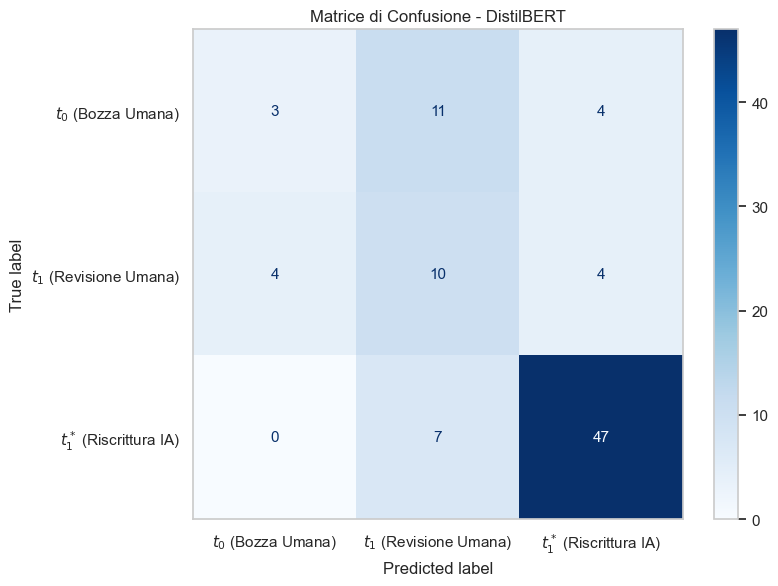

In [13]:
# inizializzazione DistilBERT
bert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3).to(device_exp2)

optimizer = AdamW(bert_model.parameters(), lr=2e-5)
epochs = 3

# definizione della loss pesata calcolata precedentemente per lo sbilanciamento 1:1:3 
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

# training Loop
print("\n[BERT] Avvio Addestramento su CPU con Loss Pesata...")
for epoch in range(epochs):
    bert_model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(train_loader, start=1):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device_exp2)
        attention_mask = batch["attention_mask"].to(device_exp2)
        labels = batch["label"].to(device_exp2)

        outputs = bert_model(input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0 or batch_idx == len(train_loader):
            print(f"  Epoch {epoch+1}/{epochs} | Batch"f" {batch_idx:>2}/{len(train_loader)} | Loss:"f" {loss.item():.4f}",end="\r")

    print(f"\n  Epoch {epoch+1} completata. Loss Media:"f" {total_loss/len(train_loader):.4f}")

bert_model.eval()
y_preds = []
y_trues = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device_exp2)
        attention_mask = batch["attention_mask"].to(device_exp2)
        labels = batch["label"].to(device_exp2)

        outputs = bert_model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        y_preds.extend(preds.cpu().numpy())
        y_trues.extend(labels.cpu().numpy())

target_names = ["$t_0$ (Bozza Umana)", "$t_1$ (Revisione Umana)", "$t_1^*$ (Riscrittura IA)"]

print("\n" + "=" * 70)
print("REPORT DI CLASSIFICAZIONE DISTILBERT")
print("=" * 70)
print(classification_report(y_trues, y_preds, target_names=target_names))

# matrice di confusione
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_trues,y_preds,display_labels=target_names,cmap="Blues",ax=ax)
plt.title("Matrice di Confusione - DistilBERT")
plt.grid(False)
plt.tight_layout()
plt.show()

### Analisi dei Risultati e della Matrice di Confusione DistilBERT

L'analisi dei risultati mostra un'**accuratezza complessiva del $\approx67%$** (60 testi corretti su 90) e un **Macro F1-Score di 0.51**. Guardando la matrice di confusione emergono alcuni aspetti sul comportamento del modello:

* **Ottima capacità nel riconoscere l'IA ($t_1^*$):** DistilBERT si dimostra molto efficace nell'individuare i testi riscritti dall'IA. Su 55 testi che il modello ha classificato come IA, ben **47 erano realmente dell'IA**, ottenendo così una precisione del **85%** con 8 falsi positivi (4 bozza $t_0$ e 4 revisione $t_1$ scambiate erroneamente per IA). In totale, il modello individua l'**87%** di tutti i testi scritti dall'IA presenti nel test set (47 su 54).
* **Confusione tra le due fasi di scrittura umana ($t_0$ e $t_1$):** il modello fatica a distinguere la prima bozza ($t_0$) dalla sua revisione ($t_1$). La matrice evidenzia infatti una forte sovrapposizione tra i due testi umani:
  * Su 18 bozze $t_0$, solo 3 vengono riconosciute correttamente, mentre **11 vengono scambiate per revisioni $t_1$**.
  * Su 18 revisioni $t_1$, 10 vengono riconosciute bene, mentre **4 vengono scambiate per bozze $t_0$**.

  Questo conferma che la scrittura e la revisione umana condividono la stessa impronta stilistica. Se raggruppassimo $t_0$ e $t_1$ in un'unica macro-classe "Umano", l'accuratezza del modello nel distinguere semplicemente Umano da IA salirebbe all'**83.3%** (**75 testi corretti su 90**).
* **Ruolo della Loss pesata e del limite di token (`max_len=128`):** l'uso della loss pesata è servito a bilanciare l'addestramento, evitando che il modello favorisse la riscrittura IA ($t_1^*$) solo perché presente con più esempi nel dataset. Il limite dei 128 token (scelto per l'addestramento su CPU) fa leggere a DistilBERT solo la parte iniziale del saggio: questo basta per individuare la "firma" dell'IA, ma probabilmnente rende difficile cogliere le piccole differenze di testo tra la bozza e la revisione dell'umano.

#### Parte 2: Baseline TF-IDF con Regressione Logistica

ESPERIMENTO 2: CLASSIFICAZIONE TF-IDF
[TF-IDF] Dimensione Vocabolario Estratto: 2000 feature

REPORT DI CLASSIFICAZIONE TF-IDF
                          precision    recall  f1-score   support

     $t_0$ (Bozza Umana)       0.50      0.06      0.10        18
 $t_1$ (Revisione Umana)       0.44      0.22      0.30        18
$t_1^*$ (Riscrittura IA)       0.66      0.96      0.78        54

                accuracy                           0.63        90
               macro avg       0.53      0.41      0.39        90
            weighted avg       0.58      0.63      0.55        90



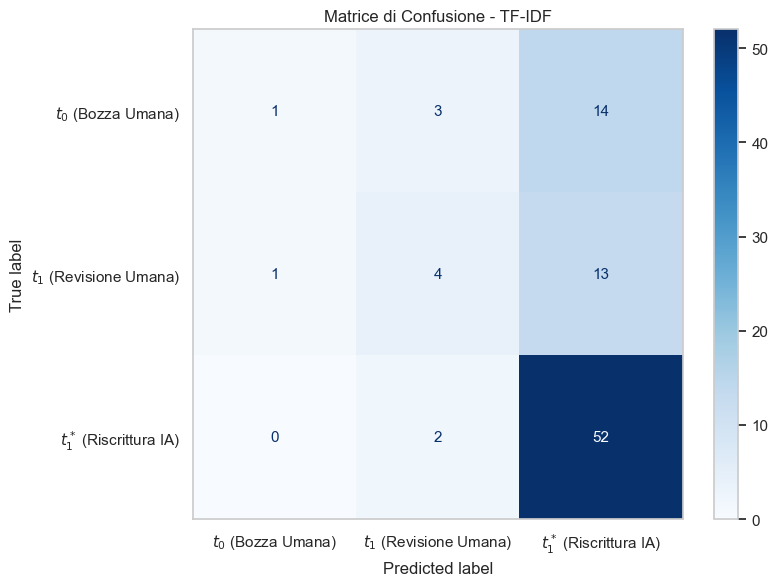

In [14]:
print("=" * 70)
print("ESPERIMENTO 2: CLASSIFICAZIONE TF-IDF")
print("=" * 70)

target_names = ["$t_0$ (Bozza Umana)", "$t_1$ (Revisione Umana)", "$t_1^*$ (Riscrittura IA)"]

# vettorializzazione TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=2000,ngram_range=(1, 1),stop_words="english",sublinear_tf=True)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"[TF-IDF] Dimensione Vocabolario Estratto: {X_train_tfidf.shape[1]} feature")

# logistic regression standard senza pesi
clf_tfidf = LogisticRegression(max_iter=1000, class_weight=None, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)

# predizione e valutazione
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

print("\n" + "=" * 70)
print("REPORT DI CLASSIFICAZIONE TF-IDF")
print("=" * 70)
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))

# matrice di confusione
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_tfidf,display_labels=target_names,cmap="Blues",ax=ax)
plt.title("Matrice di Confusione - TF-IDF")
plt.grid(False)
plt.tight_layout()
plt.show()

### Analisi dei Risultati e della Matrice di Confusione (TF-IDF)

L'analisi del modello **TF-IDF** con regressione logistica mostra un'**accuratezza complessiva del 63%** (57 testi corretti su 90) e un **Macro F1-Score di 0.39**. Rispetto a DistilBERT (**67%**), questo approccio frequenziale risente notevolmente dello sbilanciamento del dataset (1:1:3) per l'assenza di una ricalibrazione dei pesi delle classi:

* **Schiacciamento sulla classe maggioritaria ($t_1^*$):** senza l'uso di pesi bilanciati, il modello tende a predire quasi sempre la classe IA ($t_1^*$). Questo porta a una **recall altissima del 96%** sull'IA (52 testi individuati su 54), ma a una precisione che si ferma al **66%**. Il modello genera infatti diversi falsi positivi, scambiando molti testi scritti da umani per riscritture dell'IA.
* **Crollo del riconoscimento sui testi umani ($t_0$ e $t_1$):** la preferenza del modello per la classe IA penalizza fortemente il riconoscimento della scrittura umana:
    * La bozza umana ($t_0$) registra una recall di appena il **6%** (1 solo testo riconosciuto correttamente su 18).
    * La revisione umana ($t_1$) si ferma a una recall del **22%** (4 testi riconosciuti su 18).
Quasi tutti i testi umani vengono scambiati dal modello per testo generato da IA.

### Conclusioni Esperimento 2

L'Esperimento 2 ha messo a confronto un modello come **DistilBERT** con una baseline frequenziale **TF-IDF + Regressione Logistica** per valutare la capacità di distinguere la bozza dell'alunno ($t_0$), la sua revisione manuale ($t_1$) e la riscrittura generata dall'IA ($t_1^*$).

* **Superiorità di DistilBERT (67% Accuracy, Macro F1 0.51):** il fine-tuning del Transformer si attesta come il modello migliore dell'esperimento. Grazie all'uso della `CrossEntropyLoss` pesata, DistilBERT gestisce bene lo sbilanciamento delle classi (1:1:3) e riconosce il testo dell'IA con una **precisione del 85%** (47 testi corretti su 55 predizioni), producendo solo 8 falsi positivi complessivi su tutta la categoria $t_1^*$.
* **Inseparabilità Stilistica tra $t_0$ e $t_1$:** l'analisi degli errori evidenzia che la causa principale di confusione per DistilBERT non è l'IA, ma la distinzione tra la prima bozza ($t_0$) e la revisione dell'alunno ($t_1$). Le due stesure umane condividono la stessa impronta stilistica, portando il modello a scambiarle spesso tra loro (11 volte una bozza $t_0$ per una revisione $t_1$ e 4 volte una revisione $t_1$ per una bozza $t_0$). Raggruppando le due classi umane in un'unica categoria "Umano", l'accuratezza del modello nel separare Umano da IA sale aall'**83.3%** (75 testi corretti su 90).
* **Limiti di TF-IDF senza pesi (63% Accuracy, Macro F1 0.39):** TF-IDF soffre notevolmente lo sbilanciamento del dataset a causa dell'assenza di una ricalibrazione dei pesi. Il modello tende a predire quasi sempre la classe dell'IA ($t_1^*$), ottenendo un'alta recall sull'IA (**96%**), ma crollando sui testi umani (recall del **6%** per $t_0$ e del **22%** per $t_1$).

In conclusione, l'esperimento dimostra che le architetture basate su contesto come **DistilBERT**, se accompagnate da una loss pesata, sono molto più efficaci dei semplici modelli a frequenza di parole nell'individuare la "firma" dell'IA e nell'evitare che lo sbilanciamento dei dati comprometta la classificazione.

---

## Esperimento 3 - Ridondanza Interna e Omogeneizzazione Lessicale

### Obiettivo
Questo terzo esperimento estende l'analisi alla varianza semantica e stilistica, prendendo spunto dagli studi sull'omogeneizzazione generata dall'IA (es. ICLR 2026).

L'obiettivo è misurare la ridondanza interna al singolo testo e il fenomeno della convergenza lessicale-semantica nei testi prodotti dagli LLM. Si vuole verificare se, a fronte di risposte ben strutturate, gli LLM tendano a convergere verso un repertorio linguistico standardizzato.

### Metriche per quantificare l'omogeneizzazione

Per quantificare l'omogeneizzazione vengono analizzate due metriche complementari:

1. **Ricchezza Lessicale (Standardized Type-Token Ratio - STTR):**
    * **Standardized Type-Token Ratio (STTR)**: calcolato su una finestra fissa di 150 token.
    * **Distinct-N ($N \in \{1, 2, 3\}$)**: misura la quota di N-grammi unici all'interno della prima finestra di 150 token di ciascuna risposta.

2. **Omogeneizzazione Inter-Documento (Embedding Similarity)**: similarità coseno media tra gli embeddings di testi diversi dello stesso gruppo tramite `SentenceTransformer`.

### Dataset: HC3 Finance

Per questo esperimento utilizzeremo un sottoinsieme di **HC3**, focalizzato sul dominio finanziario (`Atharva07/hc3_finance`). 

Questo dataset raccoglie migliaia di domande di economia, per ciascuna delle quali abbiamo:
* **Risposta Umana:** caratterizzato da un possibile uso di gergo tecnico e da variazioni di tono tipiche dei forum umani.
* **Risposta IA (ChatGPT):** generata da IA, che potrebbe invece presentare un linguaggio più neutro e maggiormente uniforme.

Estraendo per ogni domanda esattamente una risposta umana e una sintetica, costruiremo un campione bilanciato (1:1).

In [15]:
print("=" * 70)
print("ESPERIMENTO 3: CARICAMENTO CORRETTO E CALCOLO STTR")
print("=" * 70)

# caricamento dataset
print("[INFO] Download dataset in corso...")
dataset = load_dataset("Atharva07/hc3_finance")
df_raw = pd.DataFrame(dataset['train'])

# estrazione testi
def safe_extract(val):
    if isinstance(val, list) and len(val) > 0:
        return str(val[0]).strip()
    elif isinstance(val, str) and len(val.strip()) > 0:
        return val.strip()
    return None

testi_umani = []
testi_ia = []

for idx, row in df_raw.iterrows():
    h_ans = safe_extract(row['human_answers'])
    ai_ans = safe_extract(row['chatgpt_answers'])
    
    if h_ans and ai_ans:
        testi_umani.append(h_ans)
        testi_ia.append(ai_ans)

# creazione dataframe bilanciato
df_exp3 = pd.DataFrame({
    "text": testi_umani + testi_ia,
    "label": ["Umano"] * len(testi_umani) + ["IA"] * len(testi_ia)
})

print(f"[DATA] Coppie estratte con successo: {len(testi_umani)}")
print(f"[DATA] Totale testi: {len(df_exp3)}")

ESPERIMENTO 3: CARICAMENTO CORRETTO E CALCOLO STTR
[INFO] Download dataset in corso...
[DATA] Coppie estratte con successo: 3104
[DATA] Totale testi: 6208


### Fase 1: Calcolo della Ricchezza Lessicale (TTR)

Per quantificare la varietà del vocabolario utilizzato nei due insiemi, calcoleremo il **Type-Token Ratio (TTR)**. Questa metrica mette in rapporto il numero di parole uniche (Type) con il numero totale di parole (Token) presenti in una risposta:

$$TTR = \frac{\text{Type}}{\text{Token}}$$

* **Valori più alti** indicano un testo lessicalmente ricco e variegato, tipico della scrittura umana (che include gergo, sinonimi e metafore).
* **Valori più bassi** indicano un testo ripetitivo e conservativo.

Per evitare che testi più lunghi penalizzino il punteggio, si adotta lo Standardized TTR (STTR) fisso sui primi 150 token di ogni risposta.

### Implementazione Codice

[BIAS] Testi umani validi: 1415/3104 (45.6%)
[BIAS] Testi IA validi: 2618/3104 (84.3%)
[INFO] Testi totali rimasti (≥ 150 token): 4033 su 6208


,mean,std,min,max,count
label,,,,,
IA,0.5197,0.0640,0.2733,0.6867,2618
Umano,0.6158,0.0598,0.3267,0.7800,1415


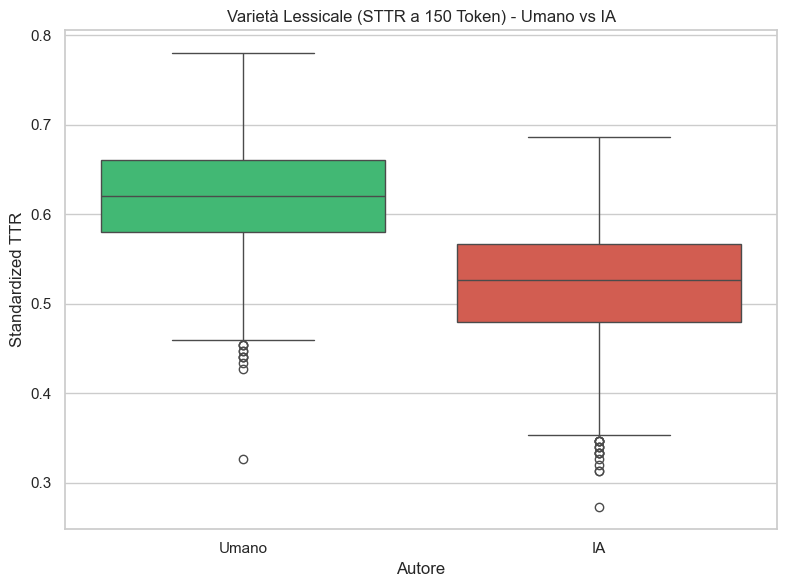

In [18]:
MAX_TOKENS = 150

def get_sttr(text, MAX_TOKENS):
    tokens = re.findall(r'\b\w+\b', text.lower())
    if len(tokens) < MAX_TOKENS:
        return None  # scarto testi con meno di 150 parole
    
    tokens_sub = tokens[:MAX_TOKENS]
    types = set(tokens_sub)
    return len(types) / len(tokens_sub)

df_exp3["STTR"] = df_exp3["text"].apply(lambda x: get_sttr(x, MAX_TOKENS))

# conteggio dei testi con almeno 150 token
human_tot = len(df_exp3[df_exp3["label"] == "Umano"])
ai_tot = len(df_exp3[df_exp3["label"] == "IA"])
human_surv = df_exp3[df_exp3["label"] == "Umano"]["STTR"].notna().sum()
ai_surv = df_exp3[df_exp3["label"] == "IA"]["STTR"].notna().sum()

print(f"[BIAS] Testi umani validi: {human_surv}/{human_tot} ({(human_surv/human_tot)*100:.1f}%)")
print(f"[BIAS] Testi IA validi: {ai_surv}/{ai_tot} ({(ai_surv/ai_tot)*100:.1f}%)")

df_clean = df_exp3.dropna(subset=["STTR"]).copy()
print(f"[INFO] Testi totali rimasti (≥ {MAX_TOKENS} token): {len(df_clean)} su {len(df_exp3)}")

stats_ttr = df_clean.groupby("label")["STTR"].agg(["mean", "std", "min", "max", "count"]).round(4)
display(stats_ttr)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x="label", y="STTR", hue="label", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("Varietà Lessicale (STTR a 150 Token) - Umano vs IA")
plt.xlabel("Autore")
plt.ylabel("Standardized TTR")
plt.tight_layout()
plt.show()

**Nota**: L'applicazione della soglia sul numero di token fa emergere una forte asimmetria strutturale. Solo circa il **46%** dei testi umani raggiunge i 150 token, contro l'84% di quelli generati dall'IA. Questo conferma che l'IA genera testi sistematicamente più lunghi.

### Analisi dei Risultati: Type-Token Ratio (STTR)

L'analisi della ricchezza lessicale, calcolata sui primi 150 token, conferma l'ipotesi di omogeneizzazione del vocabolario nell'IA:

* **Compressione Lessicale dell'IA:** il modello linguistico presenta un STTR medio di $0.52$, indicando una spiccata tendenza a riutilizzare lo stesso set di parole e congiunzioni.
* **Varianza Umana:** gli autori umani mantengono una media nettamente superiore (circa $0.62$) e raggiungono picchi di varietà molto più alti (fino a un massimo di $0.78$), un valore che l'IA non riesce a sfiorare (fermandosi a un massimo di $0.69$).
* **Significatività:** il boxplot evidenzia come l'intera distribuzione generata dall'IA sia traslata verso il basso. Il crollo della ricchezza lessicale media dell'IA rispetto all'umano è del **-15,6%**. Nonostante il dominio finanziario sia scritto con un gergo specifico, gli umani riescono a esprimere i concetti con una maggiore diversità di vocaboli rispetto al pattern di ChatGPT.

## Fase 2: Varietà Sintattica e Strutturale Intra-Testo (Distinct-N)

Per verificare la ricchezza sintattica e la tendenza alla ripetizione interna di frasi e parole, sono stati calcolati i **Distinct-N** ($N \in \{1, 2, 3\}$). 

Mentre l'omogeneizzazione *inter-documento* (ossia la convergenza stilistica tra risposte diverse) viene valutata tramite analisi di similarità, la metrica Distinct-N misura la **ricchezza espressiva nella risposta**, ossia quanto un singolo testo eviti di ripetere le strutture al suo interno.

### Controllo del Bias della Lunghezza (Legge di Heaps)

Secondo la Legge di Heaps, la varietà lessicale diminuisce all'aumentare della lunghezza del testo. Poiché i testi generati dall'IA tendono a essere più prolissi rispetto a quelli umani (come già dimostrato precdentemente), un calcolo sull'intero della risposta penalizzerebbe l'IA. Per garantire un confronto equo:

* Il calcolo viene effettuato per singola risposta applicando un **troncamento rigido alla prima finestra standard di 150 token**.
* Gli $N$-grammi vengono estratti **esclusivamente all'interno di ciascuna frase** (tramite tokenizzazione con `sent_tokenize`), evitando di creare falsi $N$-grammi a cavallo tra la fine di una frase e l'inizio della successiva.

La formula per singolo testo è:

$$\text{Distinct-N} = \frac{\text{Numero di N-grammi Unici nella finestra di 150 token}}{\text{Numero Totale di N-grammi nella finestra di 150 token}}$$

In [21]:
def calculate_distinct_n_per_doc(texts, n=2, max_tokens=150):
    scores = []
    for t in texts:
        sentences = sent_tokenize(t.lower())

        ngrams = []
        total_tokens = 0

        for sentence in sentences:
            # tokenizzazione della frase rimuovendo la punteggiatura
            tokens = [w for w in word_tokenize(sentence) if w.isalnum()]
            if not tokens:
                continue

            # calcolo di quanti token mancano per raggiungere i 150 token massimi
            remaining = max_tokens - total_tokens
            if remaining <= 0:
                break

            # tronchiamo i token della frase se superano il limite dei 150 totali
            tokens = tokens[:remaining]
            total_tokens += len(tokens)

            # estrazione degli n-grammi rispettando le condizioni
            if len(tokens) >= n:
                sentence_ngrams = [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]
                ngrams.extend(sentence_ngrams)

        if ngrams:
            score = len(set(ngrams)) / len(ngrams)
            scores.append(score)

    if not scores:
        return 0.0
    return sum(scores) / len(scores)

testi_clean_human = df_clean[df_clean["label"] == "Umano"]["text"].tolist()
testi_clean_ai = df_clean[df_clean["label"] == "IA"]["text"].tolist()

print("=" * 70)
print("ANALISI DISTINCT-N")
print("=" * 70)

results = []
for n in [1, 2, 3]:
    d_human = calculate_distinct_n_per_doc(testi_clean_human, n=n)
    d_ai = calculate_distinct_n_per_doc(testi_clean_ai, n=n)
    drop = ((d_human - d_ai) / d_human) * 100
    results.append({
        "N-Gram": f"Distinct-{n}", 
        "Umano": round(d_human, 4), 
        "IA": round(d_ai, 4), 
        "Crollo IA (%)": f"-{round(drop, 1)}%"
    })

df_distinct = pd.DataFrame(results)
display(df_distinct)

ANALISI DISTINCT-N


,N-Gram,Umano,IA,Crollo IA (%)
0,Distinct-1,0.6073,0.5134,-15.5%
1,Distinct-2,0.9251,0.8305,-10.2%
2,Distinct-3,0.9775,0.9181,-6.1%


In [ ]:
print("=" * 70)
print("ESTRAZIONE N-GRAMMI PIÙ FREQUENTI (UMANO VS IA)")
print("=" * 70)

def estrai_top_ngrams_norm(texts, n=2, top_k=5):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None, token_pattern=r"\b\w+\b").fit(texts)
    bag = vec.transform(texts)
    sum_words = bag.sum(axis=0)

    total_ngrams = sum_words.sum()  # totale n-grammi nel corpus

    # normalizzazione per 1.000 n-grammi
    words_freq = [(word, round((sum_words[0, idx] / total_ngrams) * 1000, 2)) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return pd.DataFrame(words_freq[:top_k],columns=[f"Top {n}-Grammi", "Freq. rel. (per 1k n-grammi)"],)

# estrazione bigrammi e trigrammi normalizzati
df_bi_human = estrai_top_ngrams_norm(testi_clean_human, n=2, top_k=5)
df_bi_ai = estrai_top_ngrams_norm(testi_clean_ai, n=2, top_k=5)
df_bi_comp = pd.concat([df_bi_human.add_suffix(" Umano"), df_bi_ai.add_suffix(" IA")], axis=1)

df_tri_human = estrai_top_ngrams_norm(testi_clean_human, n=3, top_k=5)
df_tri_ai = estrai_top_ngrams_norm(testi_clean_ai, n=3, top_k=5)
df_tri_comp = pd.concat([df_tri_human.add_suffix(" Umano"), df_tri_ai.add_suffix(" IA")], axis=1)

print("\n--- Confronto Bigrammi Normalizzati ---")
display(df_bi_comp)

print("\n--- Confronto Trigrammi Normalizzati ---")
display(df_tri_comp)

ESTRAZIONE N-GRAMMI PIÙ FREQUENTI (UMANO VS IA)

--- Confronto Bigrammi Normalizzati ---


,Top 2-Grammi Umano,Freq. rel. (per 1k n-grammi) Umano,Top 2-Grammi IA,Freq. rel. (per 1k n-grammi) IA
0,of the,4.86,of the,6.30
1,if you,3.96,if you,4.60
2,in the,3.73,it is,3.99
3,you can,2.56,in the,3.63
4,to the,2.32,it s,3.55



--- Confronto Trigrammi Normalizzati ---


,Top 3-Grammi Umano,Freq. rel. (per 1k n-grammi) Umano,Top 3-Grammi IA,Freq. rel. (per 1k n-grammi) IA
0,you don t,0.58,it s important,2.11
1,if you are,0.53,s important to,2.07
2,a lot of,0.42,a good idea,1.51
3,you need to,0.42,if you are,1.48
4,be able to,0.41,good idea to,1.43


### Interpretazione dei Risultati Distinct-N

L'estrazione e la normalizzazione degli n-grammi dimostrano la differenza nella struttura espressiva tra i due "autori":

1. **Unigrammi (Distinct-1: -15,5%)**: la percentuale media di vocaboli unici scende da $0.6073$ negli umani a $0.5134$ nell'IA. Il modello linguistico ricorre a un vocabolario complessivamente più ristretto, riutilizzando più frequentemente gli stessi termini all'interno della stessa risposta.
2. **Bigrammi (Distinct-2: -10,2%)**: la varietà delle coppie di parole si riduce da $0.9251$ a $0.8305$. Nelle risposte sintetiche si osserva una maggiore saturazione di bigrammi funzionali e connettivi: ad esempio, *"of the"* registra una frequenza relativa di **6.30** per 1.000 n-grammi nell'IA contro **4.86** nell'uomo, *"if you"* sale a **4.60** (vs **3.96** umano), mentre costrutti come *"it is"* (**3.99**) ed *"it s"* (**3.55**) entrano stabilmente nei primi posti dell'IA.
3. **Trigrammi (Distinct-3: -6,1%)**: la varietà dei trigrammi scende da $0.9775$ a $0.9181$. L'analisi sui dati normalizzati mette in luce la presenza di formule ricorrenti: l'IA costruisce le sue spiegazioni attorno a strutture fisse come *"it s important"* (**2.11** per 1.000 n-grammi), *"s important to"* (**2.07**), *"a good idea"* (**1.51**) e *"good idea to"* (**1.43**). Al contrario, il trigramma umano più frequente (*"you don t"*) raggiunge una frequenza di appena **0.58** per 1.000 n-grammi (quasi **4 volte inferiore** rispetto al trigramma più frequente dell'IA), dimostrando nella scrittura umana una dispersione e una naturale varietà espressiva nettamente superiori.

In [27]:
# omogeneità CROSS-RISPOSTA
model = SentenceTransformer("all-MiniLM-L6-v2")
emb_human = model.encode(testi_clean_human)
emb_ai = model.encode(testi_clean_ai)

sim_human = np.mean(cosine_similarity(emb_human))
sim_ai = np.mean(cosine_similarity(emb_ai))

print(f"Similarità media tra saggi UMANI: {sim_human:.4f}")
print(f"Similarità media tra saggi IA: {sim_ai:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Similarità media tra saggi UMANI: 0.1299
Similarità media tra saggi IA: 0.1267


#### Interpretazione della Similarità Semantica

I valori di similarità all'interno delle risposte sono quasi identici e molto bassi ($\approx 0.13$) per entrambi i gruppi. Questo risultato evidenzia un aspetto fondamentale: **l'IA non produce risposte tematicamente fotocopia tra loro**. Dal punto di vista del contenuto e del significato (spazio degli embeddings), i testi dell'IA mantengono una varietà di argomenti del tutto paragonabile a quella della produzione umana in questo dataset analizzato.

### Conclusioni dell'Esperimento 3

L'Esperimento 3 dimostra che l'impronta digitale dell'IA nei testi **non** risiede in una mancanza di varietà di contenuti, ma in una vera e propria **standardizzazione dello stile e della struttura sintattica**:

* **Diversità Semantica vs. Omogeneizzazione Stilistica:** l'analisi degli embeddings con `SentenceTransformer` conferma che i testi dell'IA mantengono un'ampia varietà tematica tra saggi diversi (similarità all'interno della risposta di circa $0.13$, pari a quella umana). Tuttavia, a parità di argomento, l'IA costruisce il discorso utilizzando sempre lo stesso stile linguistico.
* **Firma Sintattica e Formule Ricorrenti:** l'estrazione degli n-grammi rivela l'uso sistematico di formule prescrittive e di supporto. Espressioni come *"it's important to"* (**2.11** per 1.000 n-grammi) e *"a good idea to"* (**1.51** per 1.000 n-grammi) sono molto presenti nei testi sintetici, mentre risultano del tutto assenti tra le prime posizioni della scrittura umana, che mostra una variabilità espressiva molto più spontanea.
* **Riduzione della Varietà Lessicale nel Testo (Distinct-N):** anche controllando il bias della lunghezza tramite il troncamento a 150 token, il calo del **Distinct-1 (-15.5%)** e del **Distinct-2 (-10.2%)** evidenzia come l'IA tenda a ripetere gli stessi bigrammi (*"of the"*, *"if you"*, *"it is"*) all'interno dello stesso elaborato.
* **Effetto Prolissità ed Estensione:** l'analisi della lunghezza conferma un'importante asimmetria strutturale: l'**84.3%** dei testi IA supera la soglia dei 150 token, contro il solo **45.6%** dei testi umani. Tuttavia, isolando finestre di testo di pari lunghezza per eliminare il bias legato alla prolissità, la scrittura dell'IA si rivela stilisticamente più prevedibile e ridondante.

In sintesi, gli LLM offrono un'elevata chiarezza espositiva e una grande varietà di contenuti, ma al prezzo di una **omogeneizzazione delle strutture sintattiche**, restituendo testi che, seppur molto articolati, condividono una marcata e riconoscibile "impronta stilistica".